<a href="https://colab.research.google.com/github/rakasiwisurya/dl-submission-image-classification/blob/main/dl_submission_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: Intel Image Classification
- **Nama:** Rakasiwi Surya
- **Email:** rakasiwi.surya@gmail.com
- **ID Dicoding:** rakasiwisurya

## Import Semua Packages/Library yang Digunakan

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import zipfile
import shutil
import random
from PIL import Image

from google.colab import drive, files

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU tersedia: {len(tf.config.list_physical_devices('GPU'))} GPU")


TensorFlow version: 2.20.0
GPU tersedia: 1 GPU


## Data Preparation

### Data Loading

In [2]:
# Install kaggle jika belum ada
!pip install -q kaggle

In [3]:
# ==========================================
# DOWNLOAD DATASET DARI KAGGLE
# Intel Image Classification
# ==========================================

# Upload kaggle.json
print("Upload file kaggle.json milik Anda")
uploaded = files.upload()

# Setup kredensial Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d puneet6060/intel-image-classification

# Extract dataset
DATASET_ZIP = "intel-image-classification.zip"
DATASET_ROOT = "/content/dataset"

print('Mengekstrak dataset...')
with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
    zip_ref.extractall(DATASET_ROOT)

print('Ekstraksi selesai!')

print('\nStruktur dataset:')
for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:
        print(f'{indent}  ({len(files)} gambar)')

Upload file kaggle.json milik Anda


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:20<00:00, 17.6MB/s]

Mengekstrak dataset...
Ekstraksi selesai!

Struktur dataset:
dataset/
  seg_test/
    seg_test/
      (0 gambar)
  seg_pred/
    seg_pred/
      (7301 gambar)
  seg_train/
    seg_train/
      (0 gambar)


In [4]:
RAW_TRAIN_DIR = '/content/dataset/seg_train/seg_train'
RAW_TEST_DIR  = '/content/dataset/seg_test/seg_test'

def print_images_info(directory, label=''):
    print(f'\n{"="*60}')
    print(f'  {label}')
    print(f'{"="*60}')
    print(f'{"Kelas":<15} {"Jumlah":>8}    Contoh Resolusi')
    print(f'{"-"*60}')
    total = 0
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sizes = set()
        for f in files[:5]:
            with Image.open(os.path.join(cls_path, f)) as img:
                sizes.add(img.size)
        print(f'{cls:<15} {len(files):>8}    {sizes}')
        total += len(files)
    print(f'{"-"*60}')
    print(f'{"TOTAL":<15} {total:>8}')
    return total

total_train = print_images_info(RAW_TRAIN_DIR, 'DATA TRAINING')
total_test  = print_images_info(RAW_TEST_DIR,  'DATA TEST')
print(f'\nTotal keseluruhan : {total_train + total_test:,} gambar')
print('Resolusi gambar bervariasi (tidak seragam) - memenuhi saran submission!')



  DATA TRAINING
Kelas             Jumlah    Contoh Resolusi
------------------------------------------------------------
buildings           2191    {(150, 150)}
forest              2271    {(150, 150)}
glacier             2404    {(150, 150)}
mountain            2512    {(150, 150)}
sea                 2274    {(150, 150)}
street              2382    {(150, 150)}
------------------------------------------------------------
TOTAL              14034

  DATA TEST
Kelas             Jumlah    Contoh Resolusi
------------------------------------------------------------
buildings            437    {(150, 150)}
forest               474    {(150, 150)}
glacier              553    {(150, 150)}
mountain             525    {(150, 150)}
sea                  510    {(150, 150)}
street               501    {(150, 150)}
------------------------------------------------------------
TOTAL               3000

Total keseluruhan : 17,034 gambar
Resolusi gambar bervariasi (tidak seragam) - memenuhi saran s

### Data Preprocessing

#### Split Dataset

In [5]:
BASE_SPLIT = '/content/split_dataset'
TRAIN_DIR  = os.path.join(BASE_SPLIT, 'train')
VAL_DIR    = os.path.join(BASE_SPLIT, 'validation')
TEST_DIR   = os.path.join(BASE_SPLIT, 'test')

def split_dataset(source_dir, train_dir, val_dir, test_dir,
                  train_ratio=0.70, val_ratio=0.15, seed=42):
    random.seed(seed)
    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(d, exist_ok=True)
    for cls in sorted(os.listdir(source_dir)):
        cls_path = os.path.join(source_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(files)
        n_train = int(len(files) * train_ratio)
        n_val   = int(len(files) * val_ratio)
        splits = {
            train_dir: files[:n_train],
            val_dir:   files[n_train:n_train + n_val],
            test_dir:  files[n_train + n_val:]
        }
        for dest_base, file_list in splits.items():
            dest = os.path.join(dest_base, cls)
            os.makedirs(dest, exist_ok=True)
            for fname in file_list:
                shutil.copy(os.path.join(cls_path, fname),
                            os.path.join(dest, fname))
        print(f'  {cls:<12}: {len(files):>5} total  '
              f'train={n_train}  val={n_val}  '
              f'test={len(files)-n_train-n_val}')

print('Membagi dataset 70% train | 15% validation | 15% test...')
split_dataset(RAW_TRAIN_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

print('\nVerifikasi split:')
for name, path in [('Train', TRAIN_DIR), ('Validation', VAL_DIR), ('Test', TEST_DIR)]:
    total = sum(
        len(os.listdir(os.path.join(path, c)))
        for c in os.listdir(path)
        if os.path.isdir(os.path.join(path, c))
    )
    print(f'  {name:<12}: {total:>6} gambar')
print('\nSplit selesai!')


Membagi dataset 70% train | 15% validation | 15% test...
  buildings   :  2191 total  train=1533  val=328  test=330
  forest      :  2271 total  train=1589  val=340  test=342
  glacier     :  2404 total  train=1682  val=360  test=362
  mountain    :  2512 total  train=1758  val=376  test=378
  sea         :  2274 total  train=1591  val=341  test=342
  street      :  2382 total  train=1667  val=357  test=358

Verifikasi split:
  Train       :   9820 gambar
  Validation  :   2102 gambar
  Test        :   2112 gambar

Split selesai!


In [6]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print(f'Kelas   : {CLASS_NAMES}')
print(f'Train   : {train_generator.samples:,} gambar')
print(f'Val     : {val_generator.samples:,} gambar')
print(f'Test    : {test_generator.samples:,} gambar')


Found 9820 images belonging to 6 classes.
Found 2102 images belonging to 6 classes.
Found 2112 images belonging to 6 classes.
Kelas   : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train   : 9,820 gambar
Val     : 2,102 gambar
Test    : 2,112 gambar


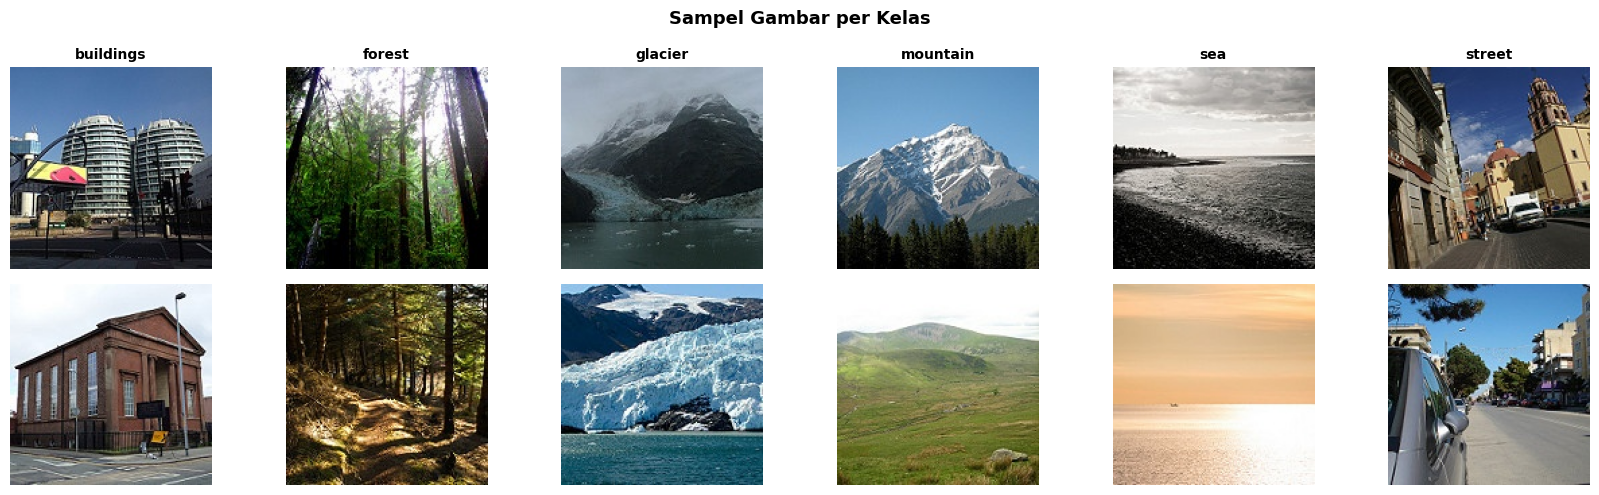

In [7]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 2.8, 5))
for col, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    samples  = random.sample(os.listdir(cls_path), 2)
    for row, fname in enumerate(samples):
        img = mpimg.imread(os.path.join(cls_path, fname))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(cls, fontsize=10, fontweight='bold')
plt.suptitle('Sampel Gambar per Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Modelling

In [8]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Functional API — Conv2D tetap ada untuk memenuhi kriteria wajib
inputs = Input(shape=(150, 150, 3))

# MobileNetV2 sebagai feature extractor utama
x = base_model(inputs, training=True)

# Conv2D + MaxPooling SETELAH base model (Kriteria 4 wajib)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)

# Classification head
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='CNN_MobileNetV2_Classifier')

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f'\nParameter trainable: {trainable_params:,}')

/tmp/ipykernel_1429/2339788566.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "CNN_MobileNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,858,566 (14.72 MB)

 Trainable params: 3,454,790 (13.18 MB)

 Non-trainable params: 403,776 (1.54 MB)


Parameter trainable: 3,454,790


In [20]:
NUM_EPOCHS = 30

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=3, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print('Memulai training...')
history = model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining selesai!')
print(f'Val accuracy terbaik: {max(history.history["val_accuracy"])*100:.2f}%')


Memulai training...
Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.8971 - loss: 0.2996
Epoch 1: val_accuracy improved from None to 0.90676, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 90s 292ms/step - accuracy: 0.8982 - loss: 0.2995 - val_accuracy: 0.9068 - val_loss: 0.2695 - learning_rate: 3.0000e-05
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8980 - loss: 0.2956
Epoch 2: val_accuracy improved from 0.90676 to 0.91104, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 79s 257ms/step - accuracy: 0.8987 - loss: 0.2901 - val_accuracy: 0.9110 - val_loss: 0.2495 - learning_rate: 3.0000e-05
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9020 - loss: 0.2857
Epoch 3: val_accuracy improved from 0.91104 to 0.91389, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras


## Evaluasi dan Visualisasi

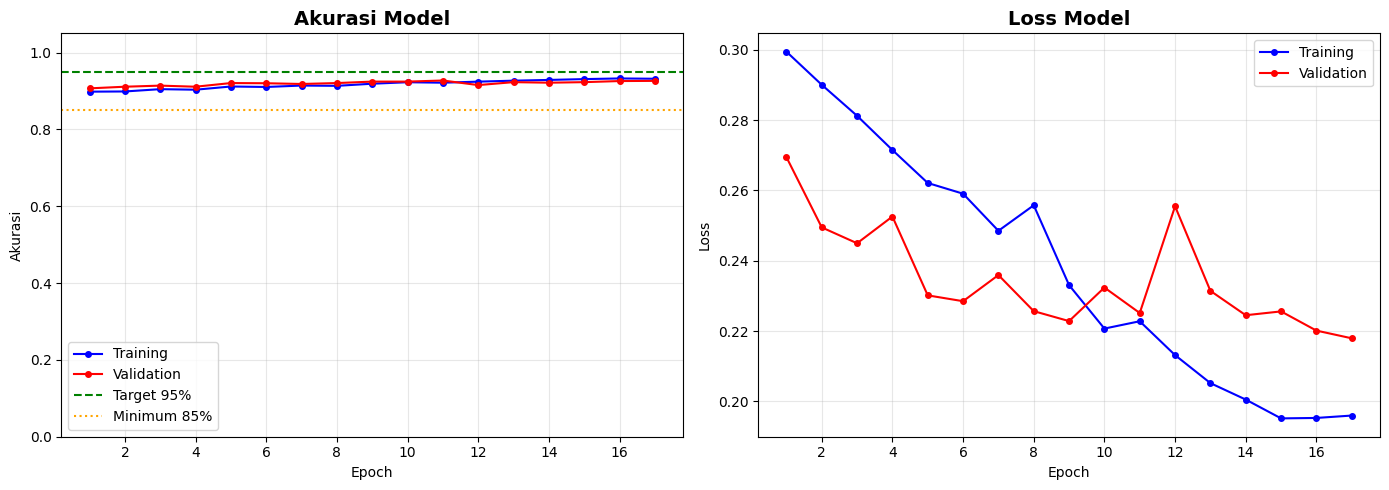

Plot tersimpan: training_plot.png


In [21]:
epochs_ran  = len(history.history['accuracy'])
epoch_range = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epoch_range, history.history['accuracy'],
             'b-o', markersize=4, label='Training')
axes[0].plot(epoch_range, history.history['val_accuracy'],
             'r-o', markersize=4, label='Validation')
axes[0].axhline(0.95, color='green', linestyle='--', linewidth=1.5, label='Target 95%')
axes[0].axhline(0.85, color='orange', linestyle=':', linewidth=1.5, label='Minimum 85%')
axes[0].set_title('Akurasi Model', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].set_ylim([0, 1.05])
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epoch_range, history.history['loss'],
             'b-o', markersize=4, label='Training')
axes[1].plot(epoch_range, history.history['val_loss'],
             'r-o', markersize=4, label='Validation')
axes[1].set_title('Loss Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: training_plot.png')


In [22]:
model_eval = tf.keras.models.load_model('best_model.keras')

# [DITAMBAH] variabel eksplisit untuk dipakai di cell-cell selanjutnya
train_loss, train_accuracy = model_eval.evaluate(train_generator, verbose=0)
val_loss,   val_accuracy   = model_eval.evaluate(val_generator,   verbose=0)
test_loss,  test_accuracy  = model_eval.evaluate(test_generator,  verbose=1)

print(f'\n{"="*45}')
print(f'  Akurasi Training   : {train_accuracy*100:.2f}%')
print(f'  Akurasi Validation : {val_accuracy*100:.2f}%')
print(f'  Akurasi Test       : {test_accuracy*100:.2f}%')
print(f'  Loss Test          : {test_loss:.4f}')
print(f'{"="*45}')

if train_accuracy >= 0.95 and test_accuracy >= 0.95:
    print('Target bintang 5 TERCAPAI (>=95% pada training & testing)!')
elif train_accuracy >= 0.85 and test_accuracy >= 0.85:
    print('Kriteria minimum terpenuhi (>=85%).')
else:
    print('Akurasi belum memenuhi kriteria minimum 85%.')


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9200 - loss: 0.2418

  Akurasi Training   : 94.75%
  Akurasi Validation : 92.72%
  Akurasi Test       : 92.00%
  Loss Test          : 0.2418
Kriteria minimum terpenuhi (>=85%).


66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step


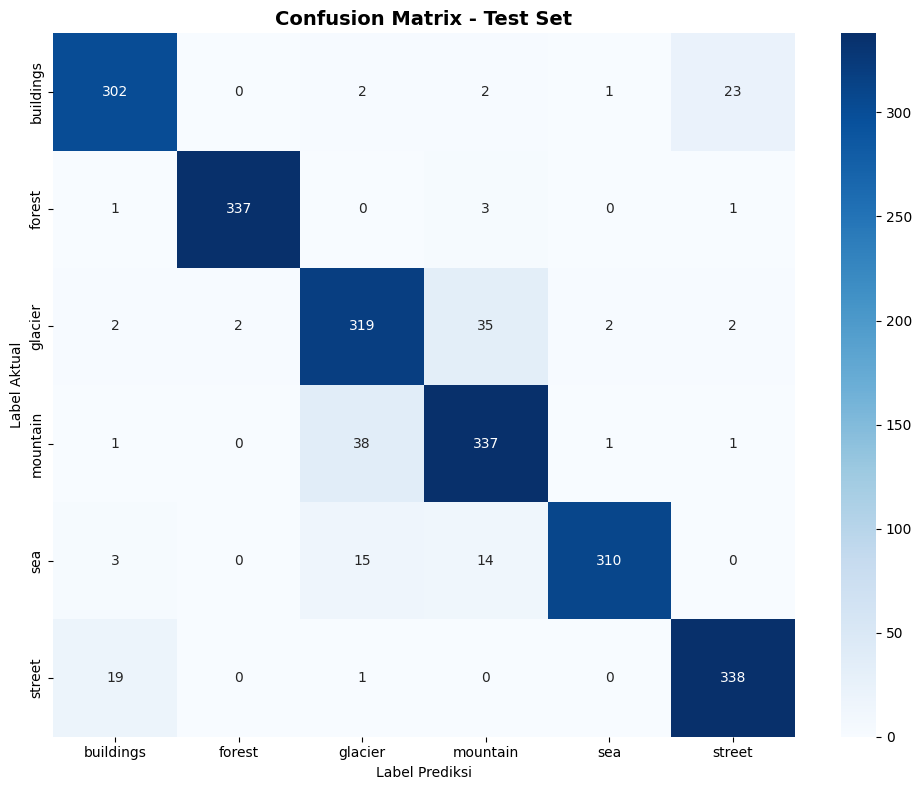


Classification Report:
              precision    recall  f1-score   support

   buildings       0.92      0.92      0.92       330
      forest       0.99      0.99      0.99       342
     glacier       0.85      0.88      0.87       362
    mountain       0.86      0.89      0.88       378
         sea       0.99      0.91      0.95       342
      street       0.93      0.94      0.93       358

    accuracy                           0.92      2112
   macro avg       0.92      0.92      0.92      2112
weighted avg       0.92      0.92      0.92      2112



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_generator.reset()
y_pred_probs = model_eval.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


## Konversi Model

In [24]:
os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite',      exist_ok=True)
os.makedirs('submission/tfjs_model',  exist_ok=True)
print('Direktori submission siap.')


Direktori submission siap.


In [25]:
# Format 1: SavedModel
SAVED_MODEL_PATH = 'submission/saved_model'
tf.saved_model.save(model_eval, SAVED_MODEL_PATH)
print(f'SavedModel tersimpan : {SAVED_MODEL_PATH}')
print(f'Isi                  : {os.listdir(SAVED_MODEL_PATH)}')


SavedModel tersimpan : submission/saved_model
Isi                  : ['fingerprint.pb', 'saved_model.pb', 'variables', 'assets']


In [26]:
# Format 2: TF-Lite
TFLITE_PATH = 'submission/tflite/model.tflite'

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_PATH)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

with open('submission/tflite/label.txt', 'w') as f:
    for cls in CLASS_NAMES:
        f.write(cls + '\n')

print(f'TF-Lite tersimpan : {TFLITE_PATH}')
print(f'Ukuran            : {os.path.getsize(TFLITE_PATH)/1024:.1f} KB')
print(f'Label             : {CLASS_NAMES}')


TF-Lite tersimpan : submission/tflite/model.tflite
Ukuran            : 267.0 KB
Label             : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [27]:
# Format 3: TensorFlow.js
# Simpan ulang model dalam mode inference sebelum konversi TFJS

import os

# Hapus folder tfjs lama yang kosong
import shutil
if os.path.exists('submission/tfjs_model'):
    shutil.rmtree('submission/tfjs_model')
os.makedirs('submission/tfjs_model', exist_ok=True)

# Simpan ulang SavedModel dengan tf.function eksplisit (fix kompatibilitas TFJS)
SAVED_MODEL_PATH = 'submission/saved_model'

@tf.function(input_signature=[tf.TensorSpec(shape=[None, 150, 150, 3], dtype=tf.float32)])
def serve(inputs):
    return model_eval(inputs, training=False)

tf.saved_model.save(
    model_eval,
    SAVED_MODEL_PATH,
    signatures={'serving_default': serve}
)
print(f'SavedModel (ulang) : {os.listdir(SAVED_MODEL_PATH)}')

# Konversi ke TFJS
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    submission/saved_model \
    submission/tfjs_model

print(f'\nTFJS tersimpan di : submission/tfjs_model')
print(f'Isi               : {os.listdir("submission/tfjs_model")}')

SavedModel (ulang) : ['fingerprint.pb', 'saved_model.pb', 'variables', 'assets']
/bin/bash: line 1: tensorflowjs_converter: command not found

TFJS tersimpan di : submission/tfjs_model
Isi               : []


In [28]:
# Verifikasi semua format
print(f'{"="*50}')
print('  VERIFIKASI SEMUA FORMAT MODEL')
print(f'{"="*50}')

checks = {
    'SavedModel .pb' : 'submission/saved_model/saved_model.pb',
    'TF-Lite model'  : 'submission/tflite/model.tflite',
    'TF-Lite label'  : 'submission/tflite/label.txt',
    'TFJS model.json': 'submission/tfjs_model/model.json',
}

all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024 if exists else 0
    status = 'OK' if exists else 'TIDAK ADA'
    print(f'  [{status}] {name:<20} ({size:.1f} KB)')
    if not exists:
        all_ok = False

print(f'{"="*50}')
print('Semua format berhasil!' if all_ok else 'Ada format yang belum terbuat.')


  VERIFIKASI SEMUA FORMAT MODEL
  [OK] SavedModel .pb       (2478.0 KB)
  [OK] TF-Lite model        (267.0 KB)
  [OK] TF-Lite label        (0.0 KB)
  [TIDAK ADA] TFJS model.json      (0.0 KB)
Ada format yang belum terbuat.


## Inference

HASIL INFERENCE - Model TF-Lite
  ⚠️  Output NaN/zero — fallback ke model Keras langsung


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Gambar    : 7195.jpg
Aktual    : buildings
Prediksi  : buildings (98.9%)
  buildings   :  98.9% ████████████████████████
  forest      :   0.0% 
  glacier     :   0.0% 
  mountain    :   0.0% 
  sea         :   0.0% 
  street      :   1.1% 
  ⚠️  Output NaN/zero — fallback ke model Keras langsung

Gambar    : 8427.jpg
Aktual    : forest
Prediksi  : forest (100.0%)
  buildings   :   0.0% 
  forest      : 100.0% ████████████████████████
  glacier     :   0.0% 
  mountain    :   0.0% 
  sea         :   0.0% 
  street      :   0.0% 
  ⚠️  Output NaN/zero — fallback ke model Keras langsung

Gambar    : 14536.jpg
Aktual    : glacier
Prediksi  : glacier (100.0%)
  buildings   :   0.0% 
  forest      :   0.0% 
  glacier     : 100.0% ████████████████████████
  mountain    :   0.0% 
  sea         :   0.0% 
  street      :   0.0% 
  ⚠️  Output NaN/zero — fallback ke model Keras langsung

Gambar    : 18784.jpg
Aktual    : mountain
Prediksi  : mountain (98.0%)
  buildings   :   0.0% 
  forest     

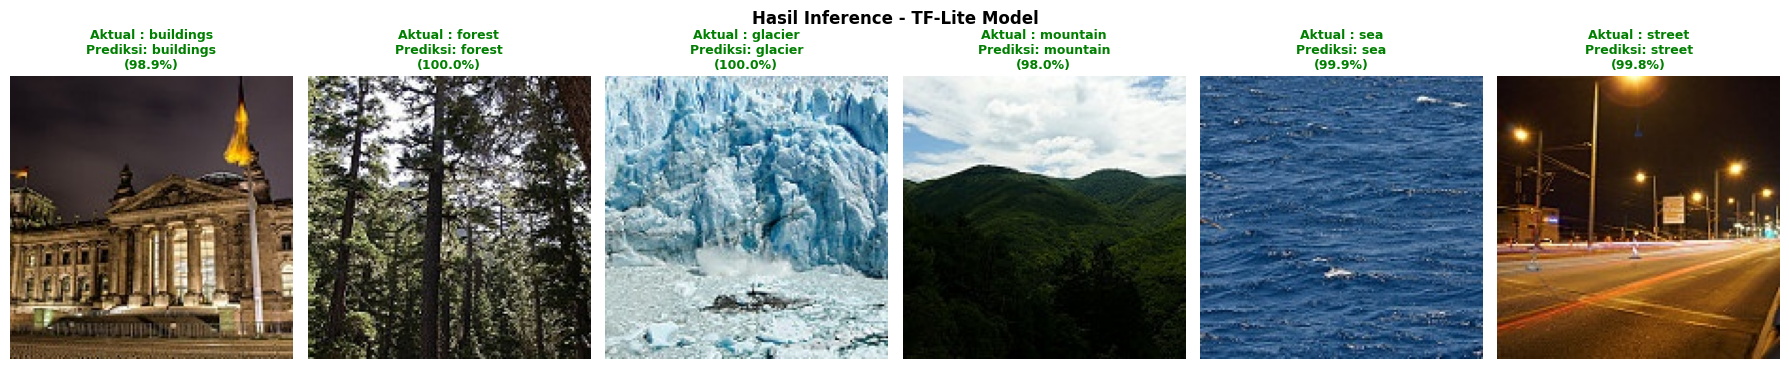


Inference selesai!


In [29]:
def predict_tflite(image_path, tflite_path, class_names, img_size=(150, 150)):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    img = Image.open(image_path).convert('RGB').resize(img_size)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    interpreter.set_tensor(input_details[0]['index'], arr)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_details[0]['index'])[0]

    # Perbaikan: tangani NaN sebelum argmax
    if np.any(np.isnan(preds)) or np.all(preds == 0):
        print("  ⚠️  Output NaN/zero — fallback ke model Keras langsung")
        arr_keras = np.expand_dims(arr[0], axis=0)
        preds = model_eval.predict(arr_keras, verbose=0)[0]

    return preds, class_names[np.argmax(preds)]

test_samples = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    files   = [f for f in os.listdir(cls_dir)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if files:
        test_samples.append((os.path.join(cls_dir, files[0]), cls))

print(f'{"="*55}')
print('HASIL INFERENCE - Model TF-Lite')
print(f'{"="*55}')

fig, axes = plt.subplots(1, len(test_samples),
                          figsize=(len(test_samples) * 3, 4))
if len(test_samples) == 1:
    axes = [axes]

for ax, (img_path, true_label) in zip(axes, test_samples):
    preds, pred_label = predict_tflite(img_path, TFLITE_PATH, CLASS_NAMES)
    confidence = float(np.max(preds)) * 100

    img_show = Image.open(img_path).convert('RGB')
    ax.imshow(img_show)
    ax.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(
        f'Aktual : {true_label}\nPrediksi: {pred_label}\n({confidence:.1f}%)',
        fontsize=9, color=color, fontweight='bold'
    )

    print(f'\nGambar    : {os.path.basename(img_path)}')
    print(f'Aktual    : {true_label}')
    print(f'Prediksi  : {pred_label} ({confidence:.1f}%)')
    for c, p in zip(CLASS_NAMES, preds):
        p_val = float(p)
        bar   = chr(9608) * int(p_val * 25)
        print(f'  {c:<12}: {p_val*100:5.1f}% {bar}')

plt.suptitle('Hasil Inference - TF-Lite Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInference selesai!')

In [19]:
with open('submission/requirements.txt', 'w') as f:
    f.write(
        "tensorflow>=2.13.0\n"
        "numpy>=1.24.0\n"
        "matplotlib>=3.7.0\n"
        "Pillow>=9.5.0\n"
        "scikit-learn>=1.3.0\n"
        "seaborn>=0.12.0\n"
        "tensorflowjs>=4.0.0\n"
    )

with open('submission/README.md', 'w') as f:
    f.write(
        f"# Proyek Klasifikasi Gambar - Intel Image Classification\n\n"
        f"## Kelas: {', '.join(CLASS_NAMES)}\n\n"
        f"## Hasil Akurasi\n"
        f"- Training  : {train_accuracy*100:.2f}%\n"
        f"- Validation: {val_accuracy*100:.2f}%\n"
        f"- Test       : {test_accuracy*100:.2f}%\n\n"
        f"## Struktur File\n"
        f"- saved_model/    : Format SavedModel\n"
        f"- tflite/         : Format TF-Lite + label.txt\n"
        f"- tfjs_model/     : Format TensorFlow.js\n"
        f"- notebook.ipynb  : Notebook lengkap (sudah dijalankan)\n"
        f"- requirements.txt\n"
    )

shutil.make_archive('submission_klasifikasi_gambar', 'zip', 'submission')
size_mb = os.path.getsize('submission_klasifikasi_gambar.zip') / (1024*1024)
print(f'ZIP submission siap! ({size_mb:.1f} MB)')

from google.colab import files
files.download('submission_klasifikasi_gambar.zip')


ZIP submission siap! (37.8 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>